# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech
## Jaya Jaya Institut - Prediksi Dropout Mahasiswa

**Business Understanding**

Jaya Jaya Institut merupakan institusi pendidikan yang telah berdiri sejak tahun 2000 dan telah mencetak banyak lulusan dengan reputasi baik. Namun, terdapat banyak siswa yang tidak menyelesaikan pendidikannya (dropout). Notebook ini bertujuan melakukan eksplorasi data, membangun model prediksi dropout, dan menarik kesimpulan untuk membantu institusi mendeteksi siswa berisiko dropout sejak dini.

**Permasalahan Bisnis**
1. Faktor-faktor apa yang paling memengaruhi apakah seorang siswa akan Dropout atau berhasil Graduate?
2. Bagaimana membangun model prediksi yang dapat mendeteksi siswa berisiko dropout sedini mungkin?

**Cakupan Proyek**
1. Data understanding & exploratory data analysis (EDA)
2. Data preparation, termasuk penentuan target pemodelan
3. Modeling (klasifikasi biner Dropout vs Graduate) & evaluasi
4. Kesimpulan dan rekomendasi action items

**Catatan metodologi:** Dataset asli memiliki 3 kategori Status: Dropout, Enrolled, dan Graduate. Karena tujuan proyek adalah memprediksi *apakah siswa akan dropout atau berhasil lulus*, siswa dengan status **Enrolled** (masih aktif kuliah, belum diketahui hasil akhirnya) **tidak disertakan dalam proses training** model, karena statusnya belum final dan akan membuat target ambigu. Data Enrolled disisihkan secara terpisah untuk keperluan prediksi di masa mendatang (begitu status akhir mereka diketahui, atau untuk deteksi dini risiko).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv("data.csv", sep=";")
df.shape


(4424, 37)

## 1. Data Understanding

In [2]:
df.head()


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [4]:
df.isna().sum().sum()  # cek missing value


np.int64(0)

Dataset bersih tanpa missing value, terdiri dari 4424 baris dan 37 kolom, termasuk kolom target `Status` (Dropout / Enrolled / Graduate).

## 2. Analisis Univariat

### 2.1 Distribusi Status Siswa (seluruh data)

/tmp/ipykernel_493/950291021.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Status', order=['Dropout', 'Enrolled', 'Graduate'], palette='Blues')


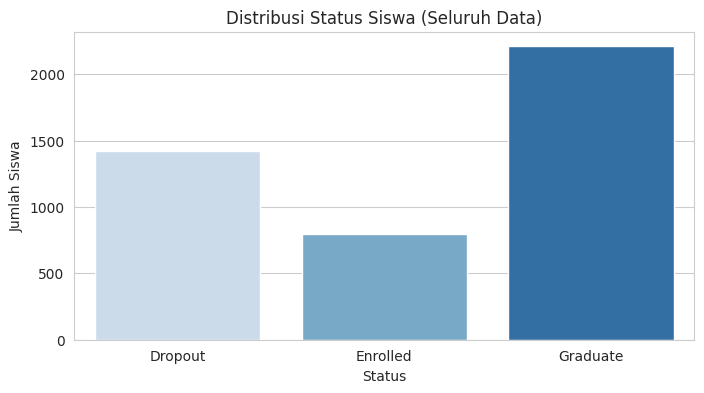

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [5]:
ax = sns.countplot(data=df, x='Status', order=['Dropout', 'Enrolled', 'Graduate'], palette='Blues')
plt.title('Distribusi Status Siswa (Seluruh Data)')
plt.ylabel('Jumlah Siswa')
plt.show()

print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True) * 100)


Terlihat 794 siswa (17.9%) masih berstatus **Enrolled**. Karena status akhir mereka (akan Dropout atau Graduate) belum diketahui, data ini akan disisihkan dari proses training model pada tahap Data Preparation, dan hanya dipakai untuk simulasi prediksi di masa mendatang.

### 2.2 Distribusi Usia dan Nilai Masuk

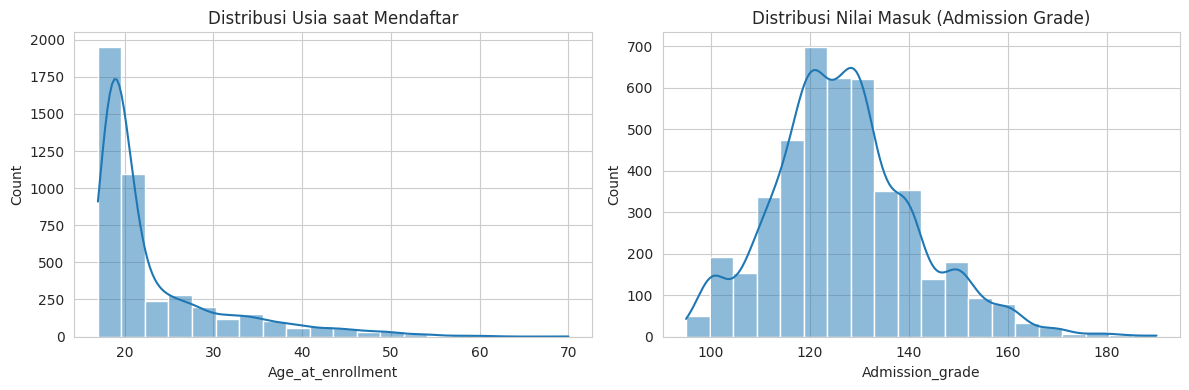

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Age_at_enrollment'], bins=20, ax=axes[0], kde=True)
axes[0].set_title('Distribusi Usia saat Mendaftar')

sns.histplot(df['Admission_grade'], bins=20, ax=axes[1], kde=True)
axes[1].set_title('Distribusi Nilai Masuk (Admission Grade)')
plt.tight_layout()
plt.show()


### 2.3 Distribusi Fitur Kategorikal Penting

/tmp/ipykernel_493/1702018372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tuition_fees_up_to_date', ax=axes[0], palette='Set2')
/tmp/ipykernel_493/1702018372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Scholarship_holder', ax=axes[1], palette='Set2')
/tmp/ipykernel_493/1702018372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[2], palette='Set2')
/tmp/ipykernel_493/1702018372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

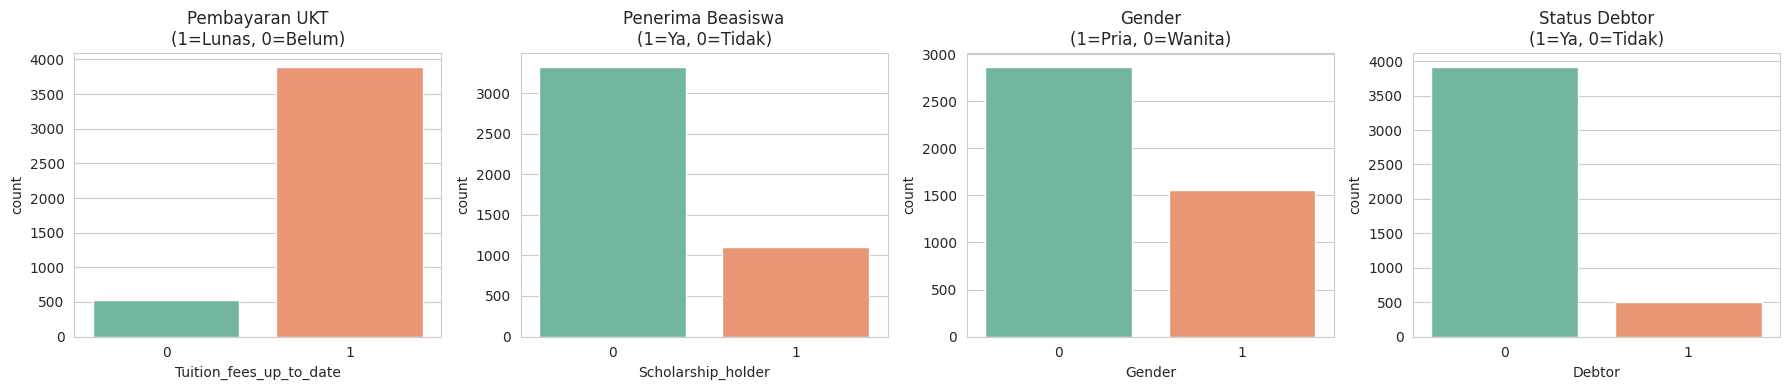

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.countplot(data=df, x='Tuition_fees_up_to_date', ax=axes[0], palette='Set2')
axes[0].set_title('Pembayaran UKT\n(1=Lunas, 0=Belum)')

sns.countplot(data=df, x='Scholarship_holder', ax=axes[1], palette='Set2')
axes[1].set_title('Penerima Beasiswa\n(1=Ya, 0=Tidak)')

sns.countplot(data=df, x='Gender', ax=axes[2], palette='Set2')
axes[2].set_title('Gender\n(1=Pria, 0=Wanita)')

sns.countplot(data=df, x='Debtor', ax=axes[3], palette='Set2')
axes[3].set_title('Status Debtor\n(1=Ya, 0=Tidak)')
plt.tight_layout()
plt.show()


## 3. Analisis Bivariat (terhadap Status, data Dropout & Graduate saja)

In [8]:
df_biv = df[df['Status'].isin(['Dropout', 'Graduate'])]


### 3.1 Status vs Jumlah Mata Kuliah Lulus (Semester 1 & 2)

/tmp/ipykernel_493/2459158760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_biv, x='Status', y='Curricular_units_1st_sem_approved',
/tmp/ipykernel_493/2459158760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_biv, x='Status', y='Curricular_units_2nd_sem_approved',


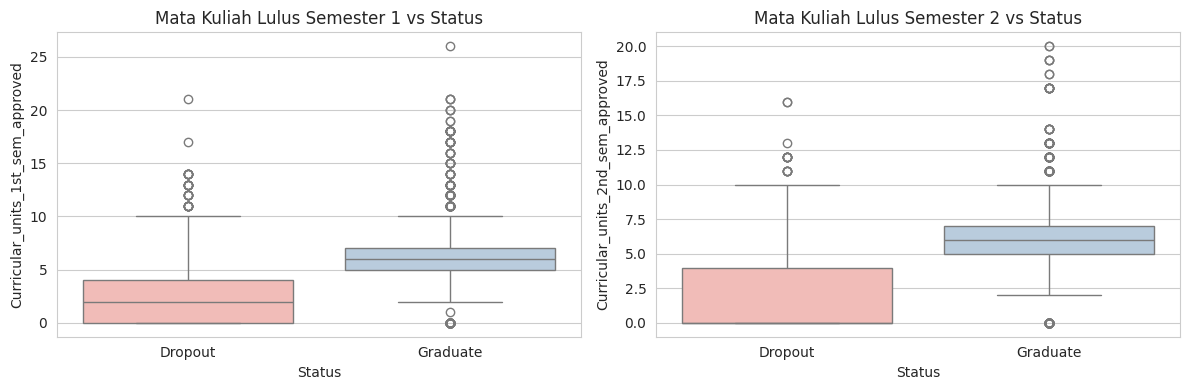

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_biv, x='Status', y='Curricular_units_1st_sem_approved',
            order=['Dropout', 'Graduate'], ax=axes[0], palette='Pastel1')
axes[0].set_title('Mata Kuliah Lulus Semester 1 vs Status')

sns.boxplot(data=df_biv, x='Status', y='Curricular_units_2nd_sem_approved',
            order=['Dropout', 'Graduate'], ax=axes[1], palette='Pastel1')
axes[1].set_title('Mata Kuliah Lulus Semester 2 vs Status')
plt.tight_layout()
plt.show()


**Insight:** Siswa yang dropout secara konsisten memiliki jumlah mata kuliah lulus yang jauh lebih rendah di kedua semester dibanding siswa yang graduate — indikasi performa akademik awal adalah sinyal kuat risiko dropout. Ini juga menjadi fitur paling penting dalam model (lihat bagian Evaluation).

### 3.2 Status vs Status Pembayaran Uang Kuliah

Status                     Dropout   Graduate
Tuition_fees_up_to_date                      
0                        94.032922   5.967078
1                        30.661578  69.338422


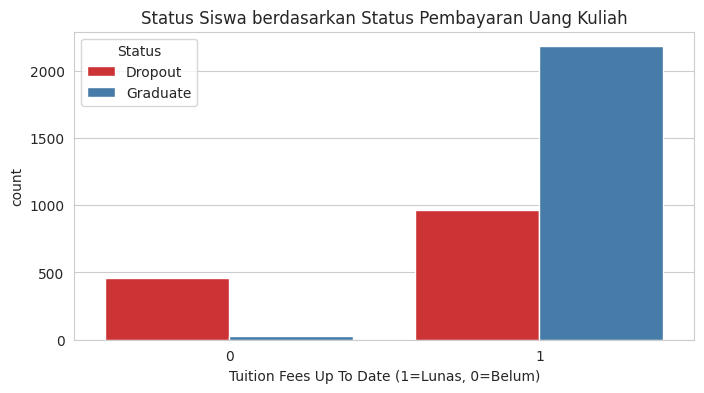

In [10]:
ct = pd.crosstab(df_biv['Tuition_fees_up_to_date'], df_biv['Status'], normalize='index') * 100
print(ct)

sns.countplot(data=df_biv, x='Tuition_fees_up_to_date', hue='Status',
              hue_order=['Dropout', 'Graduate'], palette='Set1')
plt.title('Status Siswa berdasarkan Status Pembayaran Uang Kuliah')
plt.xlabel('Tuition Fees Up To Date (1=Lunas, 0=Belum)')
plt.show()


**Insight:** Siswa yang belum melunasi uang kuliah memiliki proporsi dropout yang jauh lebih tinggi dibanding yang sudah lunas — faktor finansial menjadi salah satu pendorong dropout.

### 3.3 Status vs Beasiswa

Status                Dropout   Graduate
Scholarship_holder                      
0                   48.365276  51.634724
1                   13.828689  86.171311


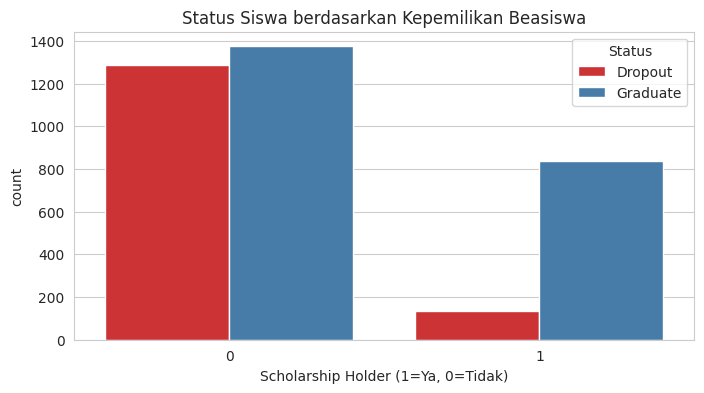

In [11]:
ct2 = pd.crosstab(df_biv['Scholarship_holder'], df_biv['Status'], normalize='index') * 100
print(ct2)

sns.countplot(data=df_biv, x='Scholarship_holder', hue='Status',
              hue_order=['Dropout', 'Graduate'], palette='Set1')
plt.title('Status Siswa berdasarkan Kepemilikan Beasiswa')
plt.xlabel('Scholarship Holder (1=Ya, 0=Tidak)')
plt.show()


**Insight:** Siswa penerima beasiswa memiliki proporsi graduate yang jauh lebih tinggi dan proporsi dropout yang jauh lebih rendah dibanding yang tidak menerima beasiswa.

## 4. Data Preparation

Sesuai catatan metodologi di atas, tahap ini melakukan:
1. **Filtering** — hanya menyertakan siswa berstatus `Dropout` dan `Graduate`. Siswa `Enrolled` disisihkan ke `enrolled_students.csv` untuk prediksi di masa mendatang, bukan untuk training.
2. **Encoding target biner** — `Dropout = 1`, `Graduate = 0`.
3. **Verifikasi keseimbangan kelas** — memastikan proporsi kedua kelas cukup seimbang untuk pemodelan yang valid.


In [12]:
df_enrolled = df[df["Status"] == "Enrolled"].copy()
df_enrolled.to_csv("enrolled_students.csv", sep=";", index=False)
print("Jumlah siswa Enrolled (disisihkan, tidak dipakai training):", len(df_enrolled))

df_model = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
print("Jumlah data untuk pemodelan (Dropout + Graduate):", len(df_model))


Jumlah siswa Enrolled (disisihkan, tidak dipakai training): 794
Jumlah data untuk pemodelan (Dropout + Graduate): 3630


In [13]:
X = df_model.drop(columns=["Status"])
y = df_model["Status"].map({"Graduate": 0, "Dropout": 1})

print("Distribusi target (0=Graduate, 1=Dropout):")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)


Distribusi target (0=Graduate, 1=Dropout):
Status
0    2209
1    1421
Name: count, dtype: int64
Status
0    60.853994
1    39.146006
Name: proportion, dtype: float64


Distribusi target cukup seimbang (~61% Graduate, ~39% Dropout), sehingga model dapat belajar pola dari kedua kelas dengan baik tanpa bias signifikan terhadap kelas mayoritas.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Data latih:", X_train.shape, " Data uji:", X_test.shape)


Data latih: (2904, 36)  Data uji: (726, 36)


## 5. Modeling

Model yang digunakan adalah **Random Forest Classifier** untuk klasifikasi biner (Dropout vs Graduate), dipilih karena robust terhadap data numerik campuran, tahan terhadap outlier, dan memberikan feature importance yang mudah diinterpretasi. Parameter `class_weight=\"balanced\"` digunakan untuk menjaga performa tetap seimbang antar kelas.

In [15]:
model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 6. Evaluation

In [16]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Graduate", "Dropout"]))


Accuracy: 0.9174
              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.93       442
     Dropout       0.91      0.87      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



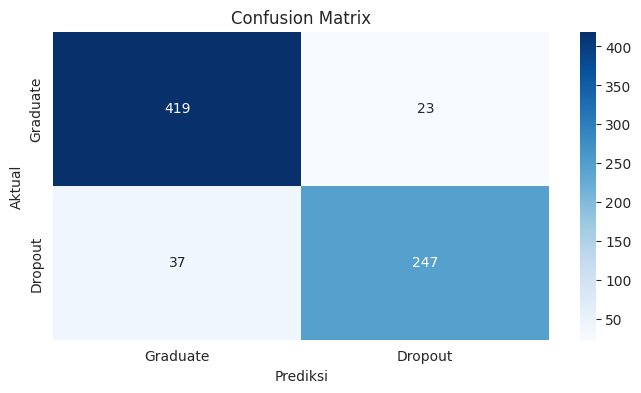

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Graduate", "Dropout"], yticklabels=["Graduate", "Dropout"])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


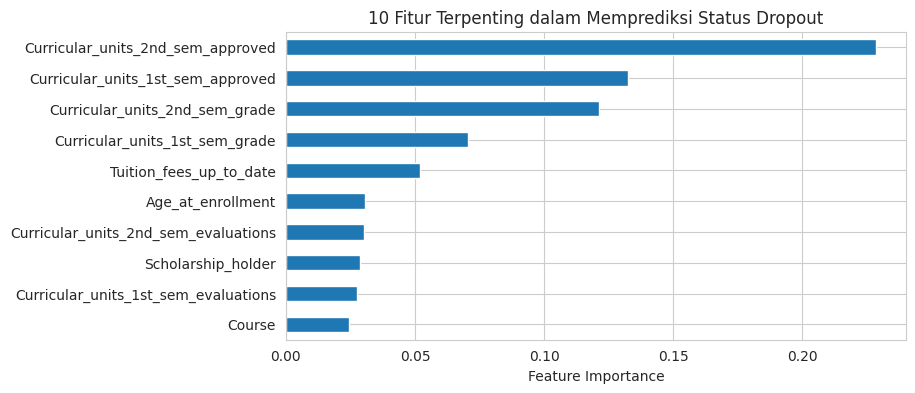

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh')
plt.title('10 Fitur Terpenting dalam Memprediksi Status Dropout')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.show()


**Insight:** Dengan pendekatan klasifikasi biner ini, model mencapai **akurasi 91.7%**, jauh lebih baik dan lebih valid dibanding pendekatan 3-kelas sebelumnya, karena target menjadi jelas dan tidak ambigu. Fitur paling berpengaruh adalah jumlah mata kuliah yang disetujui/lulus di semester 1 dan 2, nilai semester, dan status pembayaran uang kuliah.

In [19]:
joblib.dump(model, "model/model.joblib")
joblib.dump(list(X.columns), "model/feature_columns.joblib")
print("Model berhasil disimpan ke folder model/")


Model berhasil disimpan ke folder model/


## 7. Conclusion

Berdasarkan eksplorasi dan pemodelan data (dengan pendekatan klasifikasi biner Dropout vs Graduate), ditemukan tiga faktor utama yang memengaruhi risiko dropout mahasiswa Jaya Jaya Institut:

1. **Performa akademik semester 1 & 2** (jumlah mata kuliah lulus, nilai) — prediktor terkuat risiko dropout.
2. **Status pembayaran uang kuliah** — siswa yang menunggak memiliki risiko dropout jauh lebih tinggi.
3. **Kepemilikan beasiswa** — siswa penerima beasiswa jauh lebih kecil kemungkinannya untuk dropout.

Model Random Forest yang dibangun (klasifikasi biner Dropout vs Graduate) mencapai **akurasi 91.7%**, jauh lebih valid dibanding pendekatan 3-kelas karena target tidak lagi ambigu. Model ini telah disimpan dan digunakan pada prototype aplikasi berbasis Streamlit (`app.py`). Data siswa berstatus **Enrolled** (794 siswa) disisihkan secara terpisah (`enrolled_students.csv`) untuk simulasi deteksi dini risiko dropout di masa mendatang, begitu status akhir mereka diketahui.

### Rekomendasi Action Items

1. **Sistem peringatan dini akademik** — pantau mahasiswa dengan jumlah mata kuliah lulus rendah di semester 1, berikan bimbingan/tutoring tambahan sebelum semester 2 berjalan.
2. **Bantuan finansial proaktif** — identifikasi mahasiswa yang menunggak uang kuliah dan tawarkan opsi cicilan atau bantuan finansial sebelum mereka memutuskan dropout.
3. **Perluas program beasiswa** — mengingat penerima beasiswa jauh lebih kecil risikonya untuk dropout, pertimbangkan memperluas cakupan beasiswa terutama untuk mahasiswa dengan performa akademik awal yang lemah.
4. **Gunakan model prediksi secara rutin pada siswa Enrolled** — terapkan model ini pada 794 siswa yang masih aktif kuliah untuk mengidentifikasi siswa berisiko tinggi dropout sedini mungkin, sehingga intervensi dapat dilakukan sebelum mereka benar-benar keluar.
